In [1]:
!pip install matplotlib
import math
import matplotlib.pyplot as plt
import numpy as np

Defaulting to user installation because normal site-packages is not writeable


## Bisection

**Characteristics:** Brackets the root between a lower and upper limit where the function changes sign, then repeatedly halves the interval. Guaranteed linear convergence — always converges if the initial bracket is valid. Only needs function evaluations (no derivative).

**Limitations:** Requires an initial interval `[a, b]` with `f(a)` and `f(b)` of opposite sign. Slow: convergence is linear, so tight precision can take many iterations. Cannot find roots of even multiplicity where the function doesn't cross zero.

**Best use:** A reliable bracket is known and robustness matters more than speed.

**Worst use:** High precision is needed quickly, or only a single initial guess (no bracket) is available.

Iteration: 0
	Lower Limit: 5.00000e-01, Upper Limit: 1.00000e+00, Mid Point: 0.00000e+00
	Function at Lower Limit: 0.00000e+00,Function at Upper Limit: 0.00000e+00, Function at Mid Point: 0.00000e+00
	Relative Error: 0.00000e+00
Iteration: 1
	Lower Limit: 5.00000e-01, Upper Limit: 7.50000e-01, Mid Point: 7.50000e-01
	Function at Lower Limit: 6.25000e-01,Function at Upper Limit: -3.00000e+00, Function at Mid Point: -1.32812e+00
	Relative Error: 0.00000e+00
Iteration: 2
	Lower Limit: 5.00000e-01, Upper Limit: 6.25000e-01, Mid Point: 6.25000e-01
	Function at Lower Limit: 6.25000e-01,Function at Upper Limit: -1.32812e+00, Function at Mid Point: -3.80859e-01
	Relative Error: 2.00000e-01
Iteration: 3
	Lower Limit: 5.62500e-01, Upper Limit: 6.25000e-01, Mid Point: 5.62500e-01
	Function at Lower Limit: 6.25000e-01,Function at Upper Limit: -3.80859e-01, Function at Mid Point: 1.15479e-01
	Relative Error: 1.11111e-01
Iteration: 4
	Lower Limit: 5.62500e-01, Upper Limit: 5.93750e-01, Mid Point: 5.

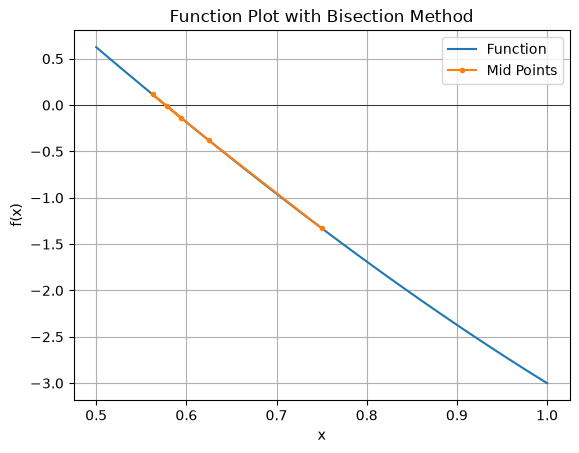

In [ ]:
def Bisection( maxIterations: int , lowerLimit: float , upperLimit: float , precision: float , function: callable, verbose: bool = False, plotting = False ) -> float:
    if plotting:
        midPoints = []
        x = np.linspace(lowerLimit, upperLimit, 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with Bisection Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        

    iteration: int = 0
    midPoint: float = 0.0
    previusMidPoint: float = 0.0
    functionAplicationLowerLimit: float = 0.0
    functionAplicationUpperLimit: float = 0.0
    functionAplicationMidPoint: float = 0.0
    relativeError: float = 0.0
    ans: float = 0.0

    if verbose:
        print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e},Function at Upper Limit: {functionAplicationUpperLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}\n\tRelative Error: {relativeError:.5e}")
    
    while iteration < maxIterations:
        if abs( upperLimit - lowerLimit ) < precision:
            ans = (lowerLimit + upperLimit) / float(2)
            break

        previusMidPoint = midPoint
        midPoint = (lowerLimit + upperLimit) / float(2)
        functionAplicationLowerLimit = function(lowerLimit)
        functionAplicationUpperLimit = function(upperLimit)
        functionAplicationMidPoint = function(midPoint)

        if iteration > 0:
            relativeError = abs((midPoint - previusMidPoint) / midPoint)

        if plotting:
            midPoints.append(midPoint)

        if abs(functionAplicationMidPoint) < precision:
            ans = midPoint
            break  

        if functionAplicationLowerLimit * functionAplicationMidPoint > 0:
            lowerLimit = midPoint
        else:
            upperLimit = midPoint

        iteration += 1
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e},Function at Upper Limit: {functionAplicationUpperLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}\n\tRelative Error: {relativeError:.5e}")
    

    
    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
        ans = (lowerLimit + upperLimit) / float(2)
    else:
        iteration += 1
        if midPoint != 0:
            relativeError = abs((midPoint - previusMidPoint) / midPoint)
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e},Function at Upper Limit: {functionAplicationUpperLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}\n\tRelative Error: {relativeError:.5e}")

    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision: {precision:.5e}")
    if plotting:    
        midPointsFx = [function(mid) for mid in midPoints]
        plt.plot(midPoints, midPointsFx, marker='.', label='Mid Points')
        plt.legend()
        plt.grid()
        plt.show()
    return ans

## Test Function

## [0.5,1] precision 0.01
function1: callable = lambda x: x**3 - (9 * x) + 5

root1: float = Bisection(100, 0.5, 1, 0.01, function1, verbose=True, plotting=True)

## False Position

**Characteristics:** Also a bracketing method, but uses the linear interpolation (secant line) between `(a, f(a))` and `(b, f(b))` instead of the midpoint. Keeps the sign-change guarantee of bisection while usually converging faster.

**Limitations:** One endpoint can get "stuck" and stop updating when the function is strongly curved/asymmetric near the root, slowing convergence toward linear. Still requires a valid bracket with opposite-sign endpoints.

**Best use:** Bracketed problems where the function is roughly linear near the root.

**Worst use:** Strongly curved/flat functions near the root (stalling), or no bracket available.


Iteration: 0
	Lower Limit: 0.00000e+00, Upper Limit: 1.00000e+00, Mid Point: 0.00000e+00
	Function at Lower Limit: 0.00000e+00, Function at Mid Point: 0.00000e+00, Function at Upper Limit: 0.00000e+00
	Relative Error: 0.00000e+00
Iteration: 1
	Lower Limit: 0.00000e+00, Upper Limit: 6.25000e-01, Mid Point: 6.25000e-01
	Function at Lower Limit: 5.00000e+00, Function at Mid Point: -3.80859e-01, Function at Upper Limit: -3.00000e+00
	Relative Error: 0.00000e+00
Iteration: 2
	Lower Limit: 0.00000e+00, Upper Limit: 5.80762e-01, Mid Point: 5.80762e-01
	Function at Lower Limit: 5.00000e+00, Function at Mid Point: -3.09780e-02, Function at Upper Limit: -3.80859e-01
	Relative Error: 7.61719e-02
Iteration: 3
	Lower Limit: 0.00000e+00, Upper Limit: 5.77186e-01, Mid Point: 5.77186e-01
	Function at Lower Limit: 5.00000e+00, Function at Mid Point: -2.39003e-03, Function at Upper Limit: -3.09780e-02
	Relative Error: 6.19560e-03
Iteration: 4
	Lower Limit: 0.00000e+00, Upper Limit: 5.77186e-01, Mid Poin

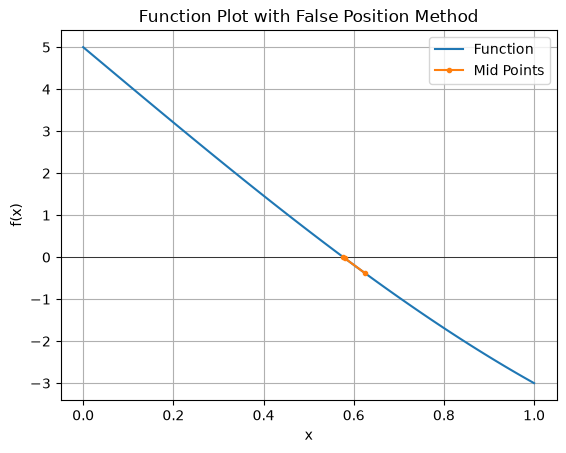

In [ ]:
def FalsePosition( maxIterations: int , lowerLimit: float , upperLimit: float , precisionLimits: float, precisontFunction: float , function: callable, verbose: bool = False, plotting: bool = False ) -> float:
    if plotting:
        midPoints = []
        x = np.linspace(lowerLimit, upperLimit, 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with False Position Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')

    
    iteration: int = 0
    midPoint: float = 0.0
    previusMidPoint: float = 0.0
    functionAplicationLowerLimit: float = 0.0
    functionAplicationUpperLimit: float = 0.0
    functionAplicationMidPoint: float = 0.0
    relativeError: float = 0.0
    ans: float = 0.0


    if verbose:
        print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}, Function at Upper Limit: {functionAplicationUpperLimit:.5e}\n\tRelative Error: {relativeError:.5e}")
    
    while iteration < maxIterations:
        if abs( upperLimit - lowerLimit ) < precisionLimits:
            break

        functionAplicationLowerLimit = function(lowerLimit)
        functionAplicationUpperLimit = function(upperLimit)
        previusMidPoint = midPoint
        midPoint = ((lowerLimit * functionAplicationUpperLimit) - (upperLimit * functionAplicationLowerLimit)) / (functionAplicationUpperLimit - functionAplicationLowerLimit)
        functionAplicationMidPoint = function(midPoint)

        if iteration > 0:  
            relativeError = abs((midPoint - previusMidPoint) / midPoint)

        if abs(functionAplicationMidPoint) < precisontFunction:
            ans = midPoint
            break
              
        if abs(functionAplicationLowerLimit) < precisontFunction:
            if plotting:    
                midPoints.append(lowerLimit)
            ans = lowerLimit
            break
            
        if abs(functionAplicationUpperLimit) < precisontFunction:
            if plotting:    
                midPoints.append(upperLimit)
            ans = upperLimit
            break

        if plotting:
            midPoints.append(midPoint)

        if functionAplicationLowerLimit * functionAplicationMidPoint > 0:
            lowerLimit = midPoint
        else:
            upperLimit = midPoint

        iteration += 1
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}, Function at Upper Limit: {functionAplicationUpperLimit:.5e}\n\tRelative Error: {relativeError:.5e}")

    
    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
        midPoint = (lowerLimit + upperLimit) / float(2)
        midPoints.append(midPoint)
        ans = midPoints
    else:
        iteration += 1
        if midPoint != 0:
            relativeError = abs((midPoint - previusMidPoint) / midPoint)
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}, Function at Upper Limit: {functionAplicationUpperLimit:.5e}\n\tRelative Error: {relativeError:.5e}")
    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision limit: {precisionLimits:.5e} and precision for function: {precisontFunction:.5e}")
    
    if plotting:    
        midPointsFx = [function(mid) for mid in midPoints]
        plt.plot(midPoints, midPointsFx, marker='.', label='Mid Points')
        plt.legend()
        plt.grid()
        plt.show()
    return ans



## Test Function

## [0,1] precision 5e-4
functionFalsePosition: callable = lambda x: x**3 - (9 * x) + 5

rootFalsePosition: float = FalsePosition(100, 0, 1, 5e-4 , 5e-4 , functionFalsePosition, verbose=True, plotting=True)

## Newton-Raphson

**Characteristics:** Uses the function and its derivative to extrapolate a tangent line to the next estimate; converges quadratically near the root. Only needs a single initial guess, not a bracket.

**Limitations:** Requires the derivative `f'(x)` to be known/computable. Can diverge, cycle, or converge to the wrong root with a poor initial guess or near-zero derivative. No sign-change safeguard.

**Best use:** Smooth functions with an easy-to-compute derivative and a good initial guess close to the root.

**Worst use:** Unknown/expensive derivatives, near-zero derivative regions, inflection points, or multiple close roots.


Iteration: 0, Current Estimate: 7.50000e-01
Iteration: 1
	Current Estimate: 7.50000e-01, Next Estimate: 5.68376e-01
	Function at Current Estimate: -1.32812e+00, Function Prime at Current Estimate: -7.31250e+00
	Relative Error: 0.00000e+00
Iteration: 2
	Current Estimate: 5.68376e-01, Next Estimate: 5.76872e-01
	Function at Current Estimate: 6.82300e-02, Function Prime at Current Estimate: -8.03085e+00
	Relative Error: 1.47277e-02
Iteration: 3
	Current Estimate: 5.68376e-01, Next Estimate: 5.76872e-01
	Function at Current Estimate: 6.82300e-02, Function Prime at Current Estimate: -8.03085e+00
	Relative Error: 1.47277e-02
Root found at: 5.76872e-01 after 3 iterations with precision difference: 1.00000e-02 and precision point: 1.00000e-02


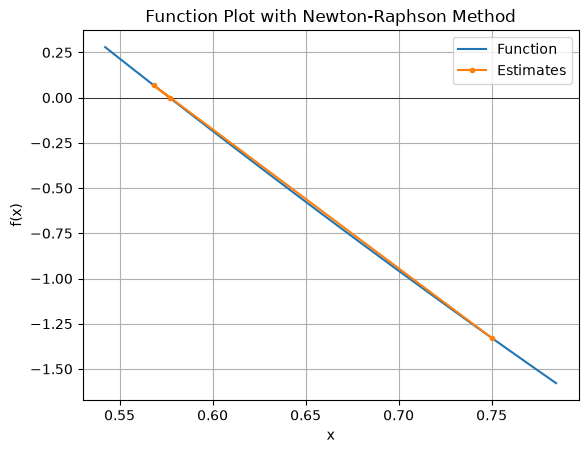

In [ ]:
def NewtonRaphson( maxIterations: int , initialEstimate: float , precisionDifference: float , precisionPoint: float , function: callable , functionPrime: callable, verbose: bool = False, plotting: bool = False ) -> float:

    if plotting:
        estimates = []
        initialPoint = initialEstimate
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with Newton-Raphson Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')

    iteration: int = 0
    previousEstimate: float = initialEstimate
    estimate: float = 0.0
    relativeError: float = 0.0
    ans: float = 0.0     
        
    if verbose:
        print(f"Iteration: {iteration}, Current Estimate: {previousEstimate:.5e}")

    while iteration < maxIterations:
        if abs(function(previousEstimate)) < precisionPoint:
            if plotting:
                estimates.append(previousEstimate)
            ans = previousEstimate
            break
        
        estimate = previousEstimate - (function(previousEstimate) / functionPrime(previousEstimate))    
        if iteration > 0:
            relativeError = abs((estimate - previousEstimate) / estimate)

        iteration += 1
        if plotting:
            estimates.append(previousEstimate)

        if verbose:
            print(f"Iteration: {iteration}\n\tCurrent Estimate: {previousEstimate:.5e}, Next Estimate: {estimate:.5e}\n\tFunction at Current Estimate: {function(previousEstimate):.5e}, Function Prime at Current Estimate: {functionPrime(previousEstimate):.5e}\n\tRelative Error: {relativeError:.5e}")

        if abs(estimate - previousEstimate) < precisionDifference or abs(function(estimate)) < precisionPoint:
            if plotting:
                estimates.append(estimate)
            ans = estimate 
            break

        previousEstimate = estimate


    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
    else:
        iteration += 1
        if estimate != 0:
            relativeError = abs((estimate - previousEstimate) / estimate)
        if verbose:
            print(f"Iteration: {iteration}\n\tCurrent Estimate: {previousEstimate:.5e}, Next Estimate: {estimate:.5e}\n\tFunction at Current Estimate: {function(previousEstimate):.5e}, Function Prime at Current Estimate: {functionPrime(previousEstimate):.5e}\n\tRelative Error: {relativeError:.5e}")
    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision difference: {precisionDifference:.5e} and precision point: {precisionPoint:.5e}")

    if plotting:
        delta = abs(0.2 *(initialPoint - estimate))
        if estimate > initialPoint:
            x = np.linspace( initialPoint - delta , estimate + delta , 100)
        else:
            x = np.linspace( estimate - delta , initialPoint + delta , 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        estimatesFx = [function(mid) for mid in estimates]
        plt.plot(estimates, estimatesFx, marker='.', label='Estimates')
        plt.legend()
        plt.grid()
        plt.show()

    return ans
## Test Function

## initial estimate 0.75 precision 1e-2
functionNewton: callable = lambda x: x**3 - (9 * x) + 5
functionNewtonPrime: callable = lambda x: 3 * (x**2) - 9

    
root1: float = NewtonRaphson(100, 0.75, 1e-2, 1e-2, functionNewton, functionNewtonPrime, verbose=True, plotting=True)

## Secant

**Characteristics:** Like Newton-Raphson but replaces the derivative with a finite-difference approximation from the last two estimates — no analytic derivative needed. Superlinear convergence (order ≈ 1.618).

**Limitations:** Needs two initial estimates (not necessarily bracketing). Can diverge if estimates are far from the root or the function is near-flat between them. No bracket safeguard.

**Best use:** Smooth functions where the derivative is unavailable/costly, with reasonable initial estimates.

**Worst use:** Poorly-behaved/noisy functions, or widely-spaced/poor initial guesses.

Iteration: 0
	Initial Estimate One: 0.00000e+00, Function at: 3.00000e+00
	Initial Estimate Two: 1.00000e+00, Function at: -5.00000e+00
	Estimate: 0.00000e+00, Function at Estimate: NILL
	, Relative Error: 0.00000e+00
Iteration: 1
	Initial Estimate One: 0.00000e+00, Function at: 3.00000e+00
	Initial Estimate Two: 1.00000e+00, Function at: -5.00000e+00
	Estimate: 3.75000e-01, Function at Estimate: -3.22266e-01
	Relative Error: 1.66667e+00
Iteration: 2
	Initial Estimate One: 1.00000e+00, Function at: -5.00000e+00
	Initial Estimate Two: 3.75000e-01, Function at: -3.22266e-01
	Estimate: 3.31942e-01, Function at Estimate: 4.91011e-02
	Relative Error: 1.29717e-01
Iteration: 3
	Initial Estimate One: 3.75000e-01, Function at: -3.22266e-01
	Initial Estimate Two: 3.31942e-01, Function at: 4.91011e-02
	Estimate: 3.37635e-01, Function at Estimate: -2.22206e-04
	Relative Error: 1.29717e-01
Root found at: 3.37635e-01 after 3 iterations with precision difference: 5.00000e-04 and precision point: 5.00

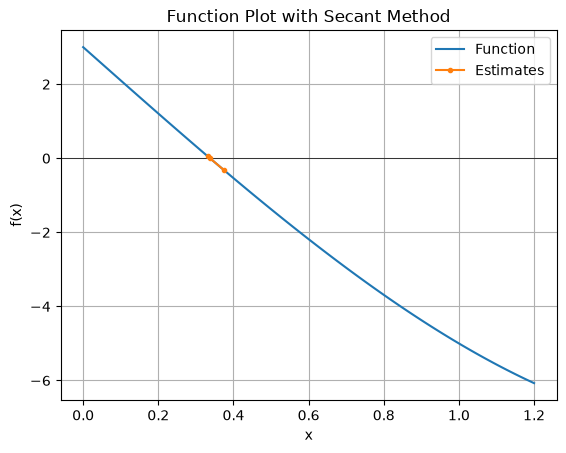

In [ ]:
def Secant( maxIterations: int , initialEstimateOne: float , initialEstimateTwo: float , precisionDifference: float , precisionPoint: float , function: callable , verbose: bool = False , plotting: bool = False ) -> float:

    if plotting:
        estimates = []
        initialPointOne = initialEstimateOne
        initialPointTwo = initialEstimateTwo
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with Secant Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')

    iteration: int = 0
    previousEstimateOne: float = initialEstimateOne
    previousEstimateTwo: float = initialEstimateTwo
    estimateOne: float = function(previousEstimateOne)
    estimateTwo: float = function(previousEstimateTwo)
    estimate: float = 0.0
    relativeError: float = 0.0
    ans: float = 0

    if verbose:
        print(f"Iteration: {iteration}\n\tInitial Estimate One: {previousEstimateOne:.5e}, Function at: {estimateOne:.5e}\n\tInitial Estimate Two: {previousEstimateTwo:.5e}, Function at: {estimateTwo:.5e}\n\tEstimate: {estimate:.5e}, Function at Estimate: NILL\n\t, Relative Error: {relativeError:.5e}")


    while iteration < maxIterations:
        if abs(estimateOne) < precisionPoint or abs(previousEstimateTwo - previousEstimateOne) < precisionDifference:
            ans = previousEstimateOne
            if plotting:
                estimates.append(previousEstimateOne)
            break

        estimate = previousEstimateTwo - ( estimateTwo * (previousEstimateTwo - previousEstimateOne) ) / (estimateTwo - estimateOne)
        if plotting:
            estimates.append(estimate)


        if abs(estimate - previousEstimateTwo) < precisionDifference or abs(function(estimate)) < precisionPoint:
            ans = estimate
            break

        relativeError = abs((estimate - previousEstimateTwo) / estimate)

        iteration += 1
        if verbose:
            print(f"Iteration: {iteration}\n\tInitial Estimate One: {previousEstimateOne:.5e}, Function at: {estimateOne:.5e}\n\tInitial Estimate Two: {previousEstimateTwo:.5e}, Function at: {estimateTwo:.5e}\n\tEstimate: {estimate:.5e}, Function at Estimate: {function(estimate):.5e}\n\tRelative Error: {relativeError:.5e}")

        previousEstimateOne = previousEstimateTwo
        previousEstimateTwo = estimate
        estimateOne = estimateTwo
        estimateTwo = function(estimate)
        
    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
        ans = estimate
    else:
        iteration += 1
        relativeError = abs((estimate - previousEstimateTwo) / estimate)
        if verbose:
            print(f"Iteration: {iteration}\n\tInitial Estimate One: {previousEstimateOne:.5e}, Function at: {estimateOne:.5e}\n\tInitial Estimate Two: {previousEstimateTwo:.5e}, Function at: {estimateTwo:.5e}\n\tEstimate: {estimate:.5e}, Function at Estimate: {function(estimate):.5e}\n\tRelative Error: {relativeError:.5e}")
    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision difference: {precisionDifference:.5e} and precision point: {precisionPoint:.5e}")

    if plotting:
        if initialPointOne > initialPointTwo:
            x = np.linspace( initialPointTwo * 0.8 , initialPointOne * 1.2 , 100)
        else:
            x = np.linspace( initialPointOne * 0.8 , initialPointTwo * 1.2 , 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        estimatesFx = [function(mid) for mid in estimates]
        plt.plot(estimates, estimatesFx, marker='.', label='Estimates')
        plt.legend()
        plt.grid()
        plt.show()


    return ans

## Test Function

## initial estimate 0.75 precision 1e-2
functionSecant: callable = lambda x: x**3 - (9 * x) + 3

    
root1: float = Secant(100, 0 , 1, 5e-4, 5e-4, functionSecant, verbose=True, plotting=True)